In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [11]:
# Load correct test sets (truly unseen — Jan 2026 → Mar 2026)
btc_test = pd.read_csv('../data/processed/BTC_USDT_test.csv')
eth_test = pd.read_csv('../data/processed/ETH_USDT_test.csv')

btc_test['timestamp'] = pd.to_datetime(btc_test['timestamp'])
eth_test['timestamp'] = pd.to_datetime(eth_test['timestamp'])

# Sort by timestamp
btc_test = btc_test.sort_values('timestamp').reset_index(drop=True)
eth_test = eth_test.sort_values('timestamp').reset_index(drop=True)

# Load best models
best_btc = joblib.load('../data/models/best_btc.joblib')    # Neural Network
best_eth = joblib.load('../data/models/best_eth.joblib')    # Random Forest
btc_scaler = joblib.load('../data/models/best_btc_scaler.joblib')

# Features
DROP_COLS = ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'future_return']
FEATURE_COLS = [c for c in btc_test.columns if c not in DROP_COLS + ['label']]

print(f"BTC test: {btc_test.shape}")
print(f"  Period: {btc_test['timestamp'].iloc[0]} → {btc_test['timestamp'].iloc[-1]}")
print(f"\nETH test: {eth_test.shape}")
print(f"  Period: {eth_test['timestamp'].iloc[0]} → {eth_test['timestamp'].iloc[-1]}")
print(f"\nFeatures: {len(FEATURE_COLS)}")

BTC test: (1983, 36)
  Period: 2025-12-31 22:00:00 → 2026-03-24 12:00:00

ETH test: (1983, 36)
  Period: 2025-12-31 22:00:00 → 2026-03-24 12:00:00

Features: 28


In [12]:
# BTC predictions (Neural Network needs scaled features)
btc_X_test = btc_test[FEATURE_COLS]
btc_X_test_sc = btc_scaler.transform(btc_X_test)
btc_test['signal'] = best_btc.predict(btc_X_test_sc)

# ETH predictions (Random Forest uses unscaled features)
eth_X_test = eth_test[FEATURE_COLS]
eth_test['signal'] = best_eth.predict(eth_X_test)

LABEL_MAP = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
btc_test['signal_label'] = btc_test['signal'].map(LABEL_MAP)
eth_test['signal_label'] = eth_test['signal'].map(LABEL_MAP)

print("BTC signal distribution:")
print(btc_test['signal_label'].value_counts())
print(f"\nETH signal distribution:")
print(eth_test['signal_label'].value_counts())

BTC signal distribution:
signal_label
HOLD    1195
BUY      722
SELL      66
Name: count, dtype: int64

ETH signal distribution:
signal_label
HOLD    1715
BUY      234
SELL      34
Name: count, dtype: int64


In [14]:
def backtest(df, symbol, initial_capital=10000):
    capital = initial_capital
    position = 0
    portfolio_values = []
    trades = []

    for i in range(len(df)):
        price = df['close'].iloc[i]
        signal = df['signal'].iloc[i]
        timestamp = df['timestamp'].iloc[i]

        if signal == 2 and capital > 0:
            position = capital / price
            capital = 0
            trades.append({'timestamp': timestamp, 'type': 'BUY', 'price': price})

        elif signal == 0 and position > 0:
            capital = position * price
            trades.append({'timestamp': timestamp, 'type': 'SELL', 'price': price})
            position = 0

        portfolio_value = capital + (position * price)
        portfolio_values.append({
            'timestamp': timestamp,
            'portfolio_value': portfolio_value,
            'price': price,
            'signal': signal
        })

    final_price = df['close'].iloc[-1]
    final_value = capital + (position * final_price)
    roi = (final_value - initial_capital) / initial_capital * 100

    portfolio_df = pd.DataFrame(portfolio_values)
    portfolio_df['peak'] = portfolio_df['portfolio_value'].cummax()
    portfolio_df['drawdown'] = (portfolio_df['portfolio_value'] - portfolio_df['peak']) / portfolio_df['peak'] * 100
    max_drawdown = portfolio_df['drawdown'].min()

    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()
    sell_trades = trades_df[trades_df['type'] == 'SELL'] if len(trades_df) > 0 else pd.DataFrame()

    bah_roi = (df['close'].iloc[-1] - df['close'].iloc[0]) / df['close'].iloc[0] * 100

    print(f"\n{'='*55}")
    print(f"{symbol} Backtesting Results (correct temporal split)")
    print(f"{'='*55}")
    print(f"Period:          {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
    print(f"Initial capital: $10,000.00")
    print(f"Final value:     ${final_value:,.2f}")
    print(f"ROI:             {roi:.2f}%")
    print(f"Max Drawdown:    {max_drawdown:.2f}%")
    print(f"Total trades:    {len(sell_trades)}")
    print(f"Buy & Hold ROI:  {bah_roi:.2f}%")
    print(f"vs Buy & Hold:   {roi - bah_roi:+.2f}%")
    print(f"{'='*55}")

    return portfolio_df, trades_df

btc_portfolio, btc_trades = backtest(btc_test, 'BTC')
eth_portfolio, eth_trades = backtest(eth_test, 'ETH')


BTC Backtesting Results (correct temporal split)
Period:          2025-12-31 22:00:00 → 2026-03-24 12:00:00
Initial capital: $10,000.00
Final value:     $9,229.34
ROI:             -7.71%
Max Drawdown:    -29.55%
Total trades:    42
Buy & Hold ROI:  -19.12%
vs Buy & Hold:   +11.41%

ETH Backtesting Results (correct temporal split)
Period:          2025-12-31 22:00:00 → 2026-03-24 12:00:00
Initial capital: $10,000.00
Final value:     $9,334.78
ROI:             -6.65%
Max Drawdown:    -24.22%
Total trades:    24
Buy & Hold ROI:  -27.37%
vs Buy & Hold:   +20.71%


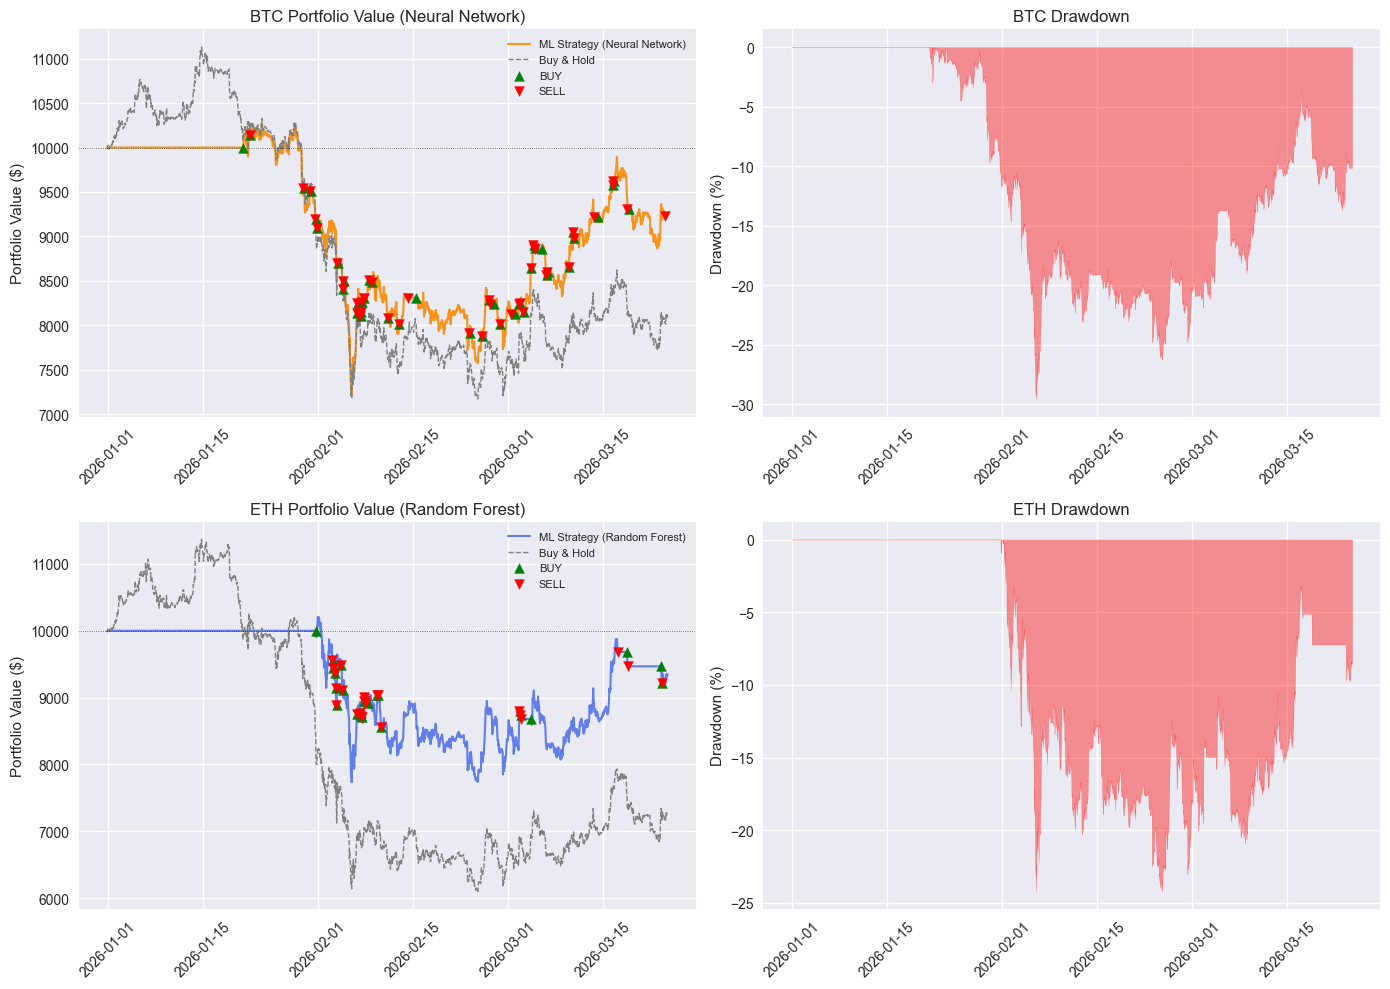

Backtest chart saved!


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (portfolio_df, trades_df, df, symbol, color, model_name) in enumerate([
    (btc_portfolio, btc_trades, btc_test, 'BTC', '#F7931A', 'Neural Network'),
    (eth_portfolio, eth_trades, eth_test, 'ETH', '#627EEA', 'Random Forest')
]):
    ax1 = axes[idx][0]
    ax2 = axes[idx][1]

    # Portfolio value
    ax1.plot(portfolio_df['timestamp'], portfolio_df['portfolio_value'],
             color=color, linewidth=1.5, label=f'ML Strategy ({model_name})')

    # Buy and Hold
    first_price = portfolio_df['price'].iloc[0]
    bah_values = 10000 / first_price * portfolio_df['price']
    ax1.plot(portfolio_df['timestamp'], bah_values,
             color='gray', linewidth=1, linestyle='--', label='Buy & Hold')

    # Mark trades
    if len(trades_df) > 0:
        buys  = trades_df[trades_df['type'] == 'BUY']
        sells = trades_df[trades_df['type'] == 'SELL']

        buy_values = []
        for _, trade in buys.iterrows():
            match = portfolio_df[portfolio_df['timestamp'] == trade['timestamp']]
            if len(match) > 0:
                buy_values.append(match['portfolio_value'].iloc[0])

        sell_values = []
        for _, trade in sells.iterrows():
            match = portfolio_df[portfolio_df['timestamp'] == trade['timestamp']]
            if len(match) > 0:
                sell_values.append(match['portfolio_value'].iloc[0])

        if buy_values:
            ax1.scatter(buys['timestamp'].iloc[:len(buy_values)],
                       buy_values, color='green', marker='^', s=50, zorder=5, label='BUY')
        if sell_values:
            ax1.scatter(sells['timestamp'].iloc[:len(sell_values)],
                       sell_values, color='red', marker='v', s=50, zorder=5, label='SELL')

    ax1.axhline(y=10000, color='black', linewidth=0.5, linestyle=':')
    ax1.set_title(f'{symbol} Portfolio Value ({model_name})')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.legend(fontsize=8)
    ax1.tick_params(axis='x', rotation=45)

    # Drawdown
    ax2.fill_between(portfolio_df['timestamp'],
                     portfolio_df['drawdown'], 0,
                     color='red', alpha=0.4)
    ax2.set_title(f'{symbol} Drawdown')
    ax2.set_ylabel('Drawdown (%)')
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/diagrams/backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Backtest chart saved!")

In [16]:
summary = pd.DataFrame([
    {
        'Symbol': 'BTC',
        'Model': 'Neural Network',
        'Final Value': '$9,229.34',
        'ROI': '-7.71%',
        'Max Drawdown': '-29.55%',
        'Total Trades': 42,
        'Buy & Hold ROI': '-19.12%',
        'vs Buy & Hold': '+11.41%'
    },
    {
        'Symbol': 'ETH',
        'Model': 'Random Forest',
        'Final Value': '$9,334.78',
        'ROI': '-6.65%',
        'Max Drawdown': '-24.22%',
        'Total Trades': 24,
        'Buy & Hold ROI': '-27.37%',
        'vs Buy & Hold': '+20.71%'
    }
])

print("\nFinal Backtesting Summary (correct temporal split):")
print("="*75)
print(summary.to_string(index=False))
print("="*75)
print("\nKey insight: Jan-Mar 2026 was a bear market.")
print("Both strategies lost money but significantly LESS than Buy & Hold.")
print("The model successfully protected capital during market downturns.")


Final Backtesting Summary (correct temporal split):
Symbol          Model Final Value    ROI Max Drawdown  Total Trades Buy & Hold ROI vs Buy & Hold
   BTC Neural Network   $9,229.34 -7.71%      -29.55%            42        -19.12%       +11.41%
   ETH  Random Forest   $9,334.78 -6.65%      -24.22%            24        -27.37%       +20.71%

Key insight: Jan-Mar 2026 was a bear market.
Both strategies lost money but significantly LESS than Buy & Hold.
The model successfully protected capital during market downturns.
